<a href="https://colab.research.google.com/github/Abhik404/Language_detection/blob/main/Language_Detection_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# **2. Load & Show Data**

In [ ]:
df = pd.read_csv("/content/Language Detection.csv")
df.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [ ]:
print(df.shape)
print(df['Language'].value_counts())

(10337, 2)
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


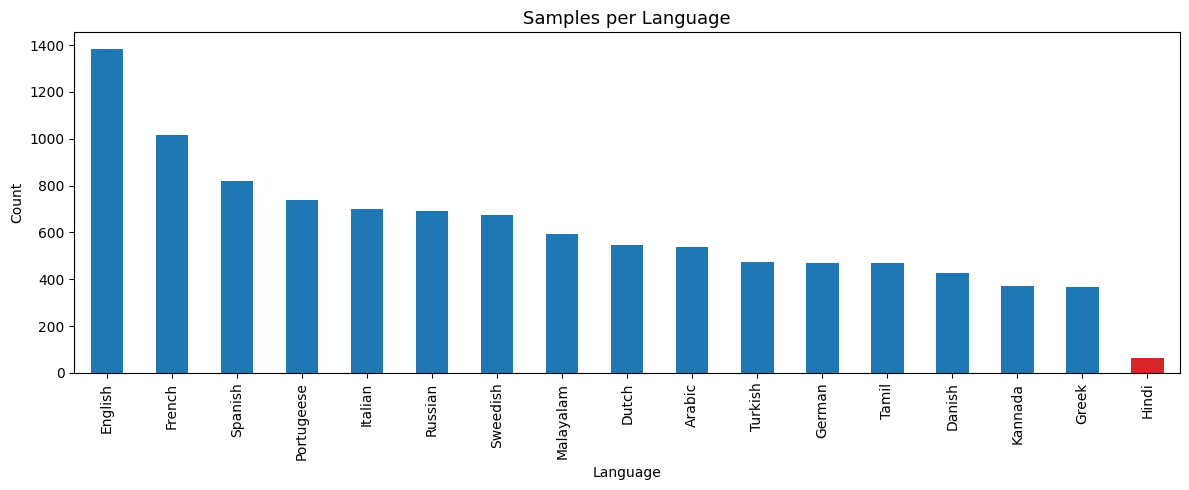


 Note - Most imbalanced: Hindi (63 samples)


In [ ]:
lang_counts = df['Language'].value_counts()

plt.figure(figsize=(12, 5))
colors = ['#d62728' if c < 200 else '#1f77b4' for c in lang_counts.values]
lang_counts.plot(kind='bar', color=colors)
plt.title('Samples per Language', fontsize=13)
plt.xlabel('Language')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"\n Note - Most imbalanced: {lang_counts.index[-1]} ({lang_counts.iloc[-1]} samples)")

# **3. Data Cleaning**

In [ ]:
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(keep='first', inplace=True)
print(f"Duplicates after:  {df.duplicated().sum()}")
print(f"Null values:\n{df.isnull().sum()}")

Duplicates before: 66
Duplicates after:  0
Null values:
Text        0
Language    0
dtype: int64


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Text_clean'] = df['Text'].apply(clean_text)
print("Original:", df['Text'][0])
print("Cleaned :", df['Text_clean'][0])

Original:  Nature, in the broadest sense, is the natural, physical, material world or universe.
Cleaned : nature in the broadest sense is the natural physical material world or universe


# **4. Train / Test Split**

In [ ]:
X = df['Text']
y = df['Language']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **5. Pipeline**

In [ ]:
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(2,5))),
    ('model', LinearSVC())
])

# **6. Hyperpareamater Tuning**

In [ ]:
param_grid = {
    'vectorizer__ngram_range': [(2,4), (2,5)],
    'model__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, verbose=2, n_jobs=-1)
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'model__C': 1, 'vectorizer__ngram_range': (2, 5)}


In [ ]:
model = grid.best_estimator_
model.fit(x_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char', ngram_range=(2, 5))),
                ('model', LinearSVC(C=1))])

# **7. Evaluate on Test Set**

In [ ]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.991727493917275

Classification Report:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       106
      Danish       1.00      0.95      0.98        85
       Dutch       1.00      0.99      1.00       108
     English       0.99      1.00      0.99       277
      French       0.98      0.99      0.98       202
      German       1.00      1.00      1.00        93
       Greek       1.00      1.00      1.00        72
       Hindi       1.00      1.00      1.00        12
     Italian       0.99      1.00      1.00       139
     Kannada       1.00      1.00      1.00        73
   Malayalam       1.00      1.00      1.00       118
  Portugeese       0.97      0.99      0.98       147
     Russian       1.00      0.99      0.99       138
     Spanish       1.00      0.97      0.98       163
    Sweedish       0.98      0.99      0.99       135
       Tamil       1.00      1.00      1.00        93
     Turkish       1.00     

# **8. Confusion Matrix**

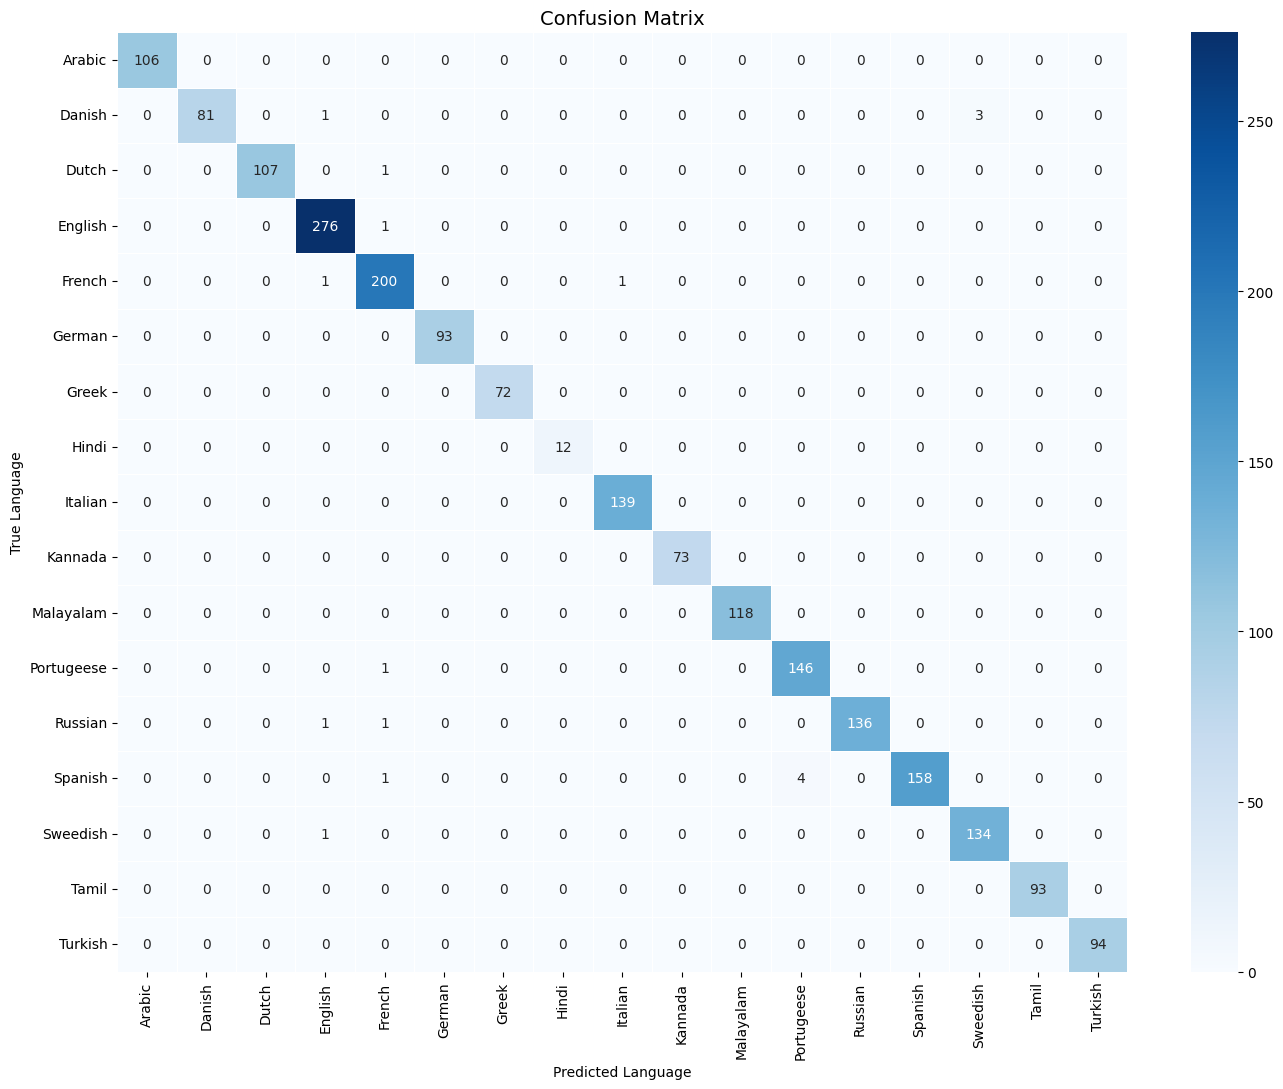

In [ ]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Language')
plt.xlabel('Predicted Language')
plt.tight_layout()
plt.show()

# **9. Train differenet Models**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

for name, mdl in models.items():
    pipe = Pipeline([
        ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(2,5))),
        ('model', mdl)
    ])

    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))


Logistic Regression
Accuracy: 0.9897810218978103

Naive Bayes
Accuracy: 0.9454987834549878

Linear SVM
Accuracy: 0.991727493917275


In [ ]:
def predict_language(text):
    text = clean_text(text)

    prediction = model.predict([text])[0]

    return prediction

# **10. Demo - Test the features**

In [ ]:
print(predict_language("This is a simple test sentence"))
print(predict_language("Ceci est une phrase française"))
print(predict_language("مرحبا كيف حالك اليوم الطقس جميل جد"))

English
French
Arabic


In [ ]:
test_texts = [
    "नमस्कार आप कैसे हैं आज मौसम बहुत सुहावना है",
    "السلام عليكم كيف حالك اليوم الطقس رائع" ,
    "வணக்கம் நீங்கள் எப்படி இருக்கிறீர்கள் இன்று வானிலை மிகவும் அழகாக உள்ளது",
    "Привет как ты сегодня погода очень хорошая" ,
    "Γεια σου πως είσαι σήμερα ο καιρός είναι πολύ καλός" ,
]

for t in test_texts:
    print(f"  {t[:45]}    → {predict_language(t)}")

  नमस्कार आप कैसे हैं आज मौसम बहुत सुहावना है    → Hindi
  السلام عليكم كيف حالك اليوم الطقس رائع    → Arabic
  வணக்கம் நீங்கள் எப்படி இருக்கிறீர்கள் இன்று வ    → Tamil
  Привет как ты сегодня погода очень хорошая    → Russian
  Γεια σου πως είσαι σήμερα ο καιρός είναι πολύ    → Greek
